# Notebook 04 — Ground Truth Labels (SOC, SOH, RUL)

## Objective
Generate the three target labels the whole project predicts: State of Charge (SOC), State of Health (SOH), and Remaining Useful Life (RUL), and merge them with the engineered features from Notebook 03.

## Why This Step Is Needed
Without ground-truth labels there is nothing to train or evaluate a model against. This notebook is also where the real battery metadata (measured Capacity per cycle) enters the pipeline for the first time.

## Workflow Position
```
01 Data Understanding -> 02 Preprocessing -> 03 Feature Engineering
-> [YOU ARE HERE] 04 Ground Truth Labels -> 05 Model Training (AHRF) -> 06 Model Comparison
-> 07 Explainability (SHAP) -> 08 Decision Engine & Summary
```


## 1. Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from src.core.config import FEATURE_DATA, RATED_CAPACITY_AH, EOL_SOH_THRESHOLD
from src.core.data_loader import load_metadata
from src.labels.ground_truth import generate_soc_labels, generate_soh_labels, generate_rul_labels

plt.rcParams["figure.figsize"] = (10, 5)


In [3]:
discharge_features = pd.read_csv(FEATURE_DATA / "discharge_features.csv")
print("Loaded feature dataset:", discharge_features.shape)


Loaded feature dataset: (168, 70)


## 2. SOC Labels

We use a voltage-based proxy for SOC: mean discharge voltage, min-max normalized to a 0-100 scale.

**Honest limitation (state this in your report):** this is a voltage-based proxy, not a true Coulomb-counted SOC, since NASA's dataset does not provide a direct SOC ground truth. This is a common, accepted approach at student-project level, but should be described accurately rather than implied to be a precise physical measurement.


In [4]:
discharge_features = generate_soc_labels(discharge_features)
discharge_features[["File", "cycle_index", "SOC"]].head()


,File,cycle_index,SOC
0,05122.csv,1,65.753492
1,05124.csv,2,73.238830
2,05126.csv,3,79.650187
3,05128.csv,4,79.579624
4,05130.csv,5,78.257850


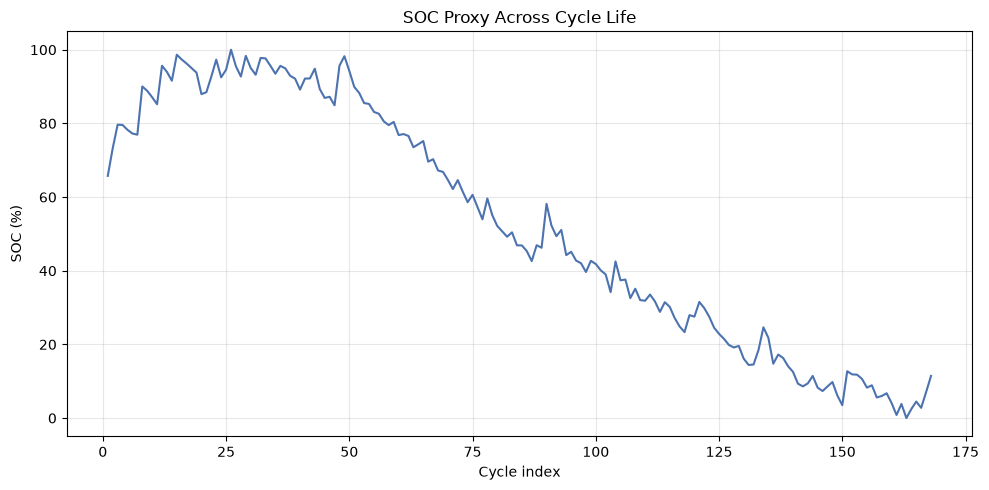

In [5]:
fig, ax = plt.subplots()
ax.plot(discharge_features["cycle_index"], discharge_features["SOC"], color="#4C72B0")
ax.set_title("SOC Proxy Across Cycle Life")
ax.set_xlabel("Cycle index")
ax.set_ylabel("SOC (%)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Observation
Since this SOC proxy is derived from average discharge voltage, it should NOT show a strong monotonic trend across cycle life the way SOH will -- it reflects within-cycle voltage level, which is a different kind of signal (see the project's system architecture notes on why SOC and SOH/RUL use separate feature logic).


## 3. SOH Labels

SOH is computed as `(measured capacity at this cycle / rated capacity) * 100`, merging the discharge features with the real `Capacity` values from `metadata.csv`.


In [6]:
metadata = load_metadata()
print(f"Rated capacity assumption: {RATED_CAPACITY_AH} Ah")

soh_df = generate_soh_labels(discharge_features, metadata)
soh_df[["File", "cycle_index", "Capacity", "SOH (%)"]].head()


load_metadata(): cleaned 7566 bad/duplicate rows (15131 -> 7565).
Rated capacity assumption: 2.0 Ah


,File,cycle_index,Capacity,SOH (%)
0,05122.csv,1,1.856487,92.824371
1,05124.csv,2,1.846327,92.316363
2,05126.csv,3,1.835349,91.767460
3,05128.csv,4,1.835263,91.763126
4,05130.csv,5,1.834646,91.732275


In [7]:
print("Missing SOH values after merge:", soh_df["SOH (%)"].isna().sum())
print("\nSOH range:", soh_df["SOH (%)"].min().round(2), "to", soh_df["SOH (%)"].max().round(2))


Missing SOH values after merge: 0

SOH range: 64.37 to 92.82


### Observation
`Missing SOH values after merge` should be 0 -- if it's not, the `File` values in the feature dataset don't match the `filename` values in metadata exactly (check for whitespace or casing differences). The SOH range shows how much this battery degraded across the available cycles.


## 4. Visualize the Degradation Curve (SOH vs. Cycle)

This is one of the most important figures in the whole report -- it's the direct visual evidence of battery aging that everything else is built on.


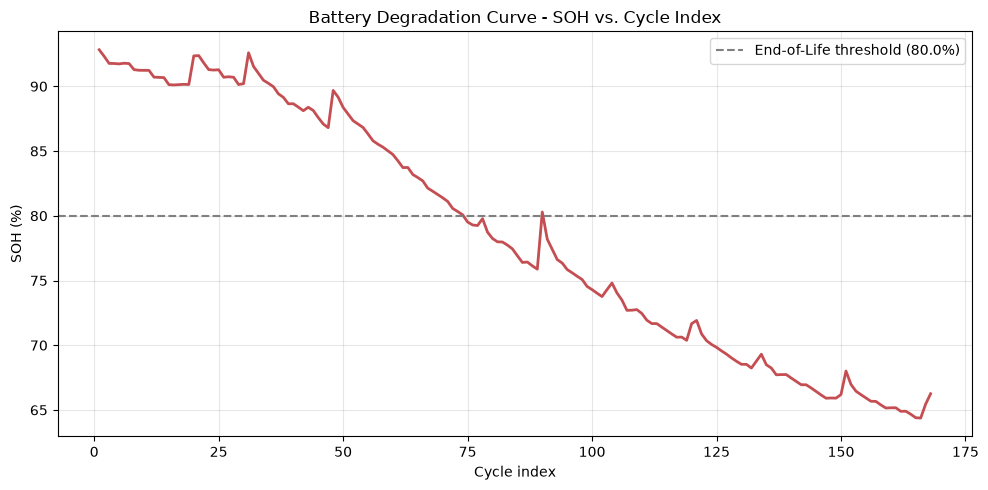

In [8]:
fig, ax = plt.subplots()
ax.plot(soh_df["cycle_index"], soh_df["SOH (%)"], color="#C44E52", linewidth=2)
ax.axhline(EOL_SOH_THRESHOLD, color="gray", linestyle="--", label=f"End-of-Life threshold ({EOL_SOH_THRESHOLD}%)")
ax.set_title("Battery Degradation Curve - SOH vs. Cycle Index")
ax.set_xlabel("Cycle index")
ax.set_ylabel("SOH (%)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Observation
SOH should decrease roughly monotonically (with some natural noise/regeneration bumps -- a real, documented Li-ion phenomenon, not a data error) as cycle index increases. Note where the curve crosses the End-of-Life threshold line -- this is the point RUL is computed relative to.


## 5. RUL Labels

RUL for each cycle = number of cycles remaining until SOH first drops to/below the End-of-Life threshold.


In [9]:
rul_df = generate_rul_labels(soh_df)
rul_df[["cycle_index", "SOH (%)", "RUL"]].head()


,cycle_index,SOH (%),RUL
0,1,92.824371,74.0
1,2,92.316363,73.0
2,3,91.767460,72.0
3,4,91.763126,71.0
4,5,91.732275,70.0


In [10]:
rul_df[["cycle_index", "SOH (%)", "RUL"]].tail()


,cycle_index,SOH (%),RUL
163,164,64.673181,0.0
164,165,64.400170,0.0
165,166,64.372626,0.0
166,167,65.450768,0.0
167,168,66.253966,0.0


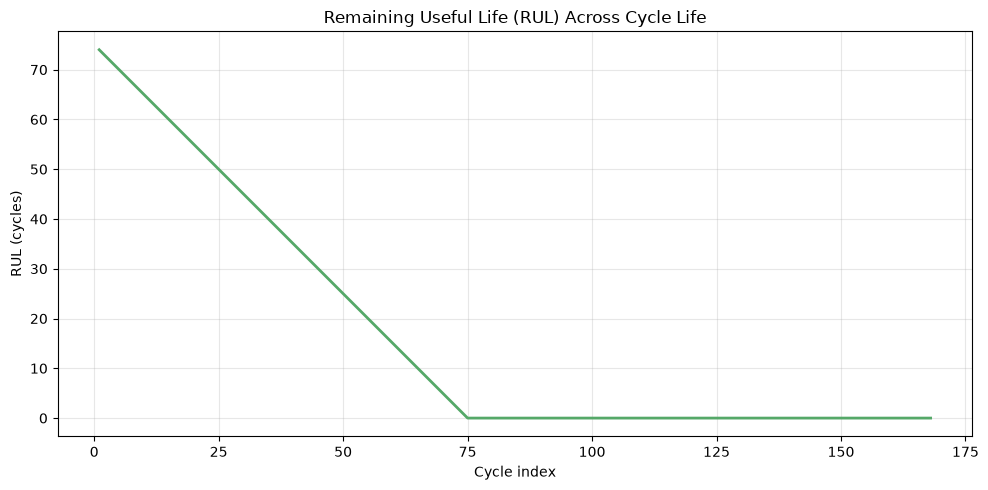

In [11]:
fig, ax = plt.subplots()
ax.plot(rul_df["cycle_index"], rul_df["RUL"], color="#55A868", linewidth=2)
ax.set_title("Remaining Useful Life (RUL) Across Cycle Life")
ax.set_xlabel("Cycle index")
ax.set_ylabel("RUL (cycles)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Observation
RUL should decrease roughly linearly as cycle index increases, and should be exactly 0 for every cycle after the battery first crosses the End-of-Life threshold (early cycles have never seen it, so this is expected). This is a good sanity check that the label logic is correct.


## 6. Combined Dataset Overview


In [12]:
print("Final combined dataset shape:", rul_df.shape)
rul_df[["File", "cycle_index", "SOC", "SOH (%)", "RUL"]].describe()


Final combined dataset shape: (168, 75)


,cycle_index,SOC,SOH (%),RUL
count,168.000000,168.000000,168.000000,168.000000
mean,84.500000,52.722832,78.625103,16.517857
std,48.641546,32.699809,9.520639,23.469683
min,1.000000,0.000000,64.372626,0.000000
25%,42.750000,22.599260,69.501039,0.000000
50%,84.500000,50.566228,77.854273,0.000000
75%,126.250000,86.968023,88.458126,32.250000
max,168.000000,100.000000,92.824371,74.000000


## 7. Save the Full Labeled Dataset


In [13]:
output_path = FEATURE_DATA / "full_labeled_dataset.csv"
rul_df.to_csv(output_path, index=False)
print("Saved to:", output_path)

# Also save SOH-only and RUL-only convenience files, matching the earlier
# project structure (dataset/features/soh_dataset.csv, rul_dataset.csv)
rul_df.to_csv(FEATURE_DATA / "soh_dataset.csv", index=False)
rul_df.to_csv(FEATURE_DATA / "rul_dataset.csv", index=False)


Saved to: C:\BE PROJECT\SBMS_PROJECT\dataset\features\full_labeled_dataset.csv


## Results Summary

| Label | Range | Notes |
|---|---|---|
| SOC | 0-100% | Voltage-based proxy |
| SOH | See Section 3 output | `(Capacity / rated_capacity) * 100` |
| RUL | See Section 5 output | Cycles until SOH <= 80% threshold |

## Conclusion
All three target labels have been generated and merged with the engineered features into one combined dataset (`full_labeled_dataset.csv`). The degradation curve confirms the expected physical behavior (SOH decreasing over cycle life), and RUL correctly reaches 0 once the End-of-Life threshold is crossed.

## Next Steps
Notebook 05 will split this dataset chronologically (not randomly -- see the project's evaluation methodology notes) and train both the baseline Random Forest and our AHRF model for SOH prediction (and SOC/RUL following the same pattern).
